# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hfc143a"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[5.025 5.025 5.025 ... 6.328 6.328 6.328] [5.025 5.025 5.025 ... 6.328 6.328 6.328] [5.025 5.025 5.025 ... 6.328 6.328 6.328] [5.025 5.025 5.025 ... 6.328 6.328 6.328] [5.025 5.025 5.025 ... 6.328 6.328 6.328] [5.025 5.025 5.025 ... 6.328 6.328 6.328]] [[5.117 5.117 5.117 ... 6.356 6.356 6.356] [5.117 5.117 5.117 ... 6.356 6.356 6.356] [5.117 5.117 5.117 ... 6.356 6.356 6.356] [5.117 5.117 5.117 ... 6.356 6.356 6.356] [5.117 5.117 5.117 ... 6.356 6.356 6.356] [5.117 5.117 5.117 ... 6.356 6.356 6.356]] [[5.167 5.167 5.167 ... 6.373 6.373 6.373] [5.167 5.167 5.167 ... 6.373 6.373 6.373] [5.167 5.167 5.167 ... 6.373 6.373 6.373] [5.167 5.167 5.167 ... 6.373 6.373 6.373] [5.167 5.167 5.167 ... 6.373 6.373 6.373] [5.167 5.167 5.167 ... 6.373 6.373 6.373]] ... [[30.374 30.374 30.374 ... 32.913000000000004 32.790000000000006 32.667] [30.374 30.374 30.374 ... 32.913 32.790000000000006 32.667] [30.374 30.374 30.374 ... 32.646 32.79 32.667] [30.374 30.374 30.374 ... 33.258 32.962500000000006 32.667] [30.374 30.374 30.374 ... 33.0855 32.79 32.667] [30.374 30.374 30.374 ... 32.913000000000004 32.79 32.667]] [[30.598 30.598 30.598 ... 33.13166666666666 33.07633333333333 33.021] [30.598 30.598 30.598 ... 33.13166666666666 33.07633333333333 33.021] [30.598 30.598 30.598 ... 33.023 33.07633333333333 33.021] [30.598 30.598 30.598 ... 33.42933333333333 33.22516666666667 33.021] [30.598 30.598 30.598 ... 33.280499999999996 33.07633333333333 33.021] [30.598 30.598 30.598 ... 33.13166666666666 33.07633333333333 33.021]] [[30.666 30.666 30.666 ... 33.349666666666664 33.39933333333333 33.449] [30.666 30.666 30.666 ... 33.34966666666666 33.39933333333333 33.449] [30.666 30.666 30.666 ... 33.28075 33.399333333333324 33.449] [30.666 30.666 30.666 ... 33.465333333333334 33.457166666666666 33.449] [30.666 30.666 30.666 ... 33.4075 33.39933333333333 33.449] [30.666 30.666 30.666 ... 33.349666666666664 33.39933333333333 33.449]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[5.025 5.025 5.025 ... 6.328 6.328 6.328] [5.025 5.025 5.025 ... 6.328 6.328 6.328] [5.025 5.025 5.025 ... 6.328 6.328 6.328] [5.025 5.025 5.025 ... 6.328 6.328 6.328] [5.025 5.025 5.025 ... 6.328 6.328 6.328] [5.025 5.025 5.025 ... 6.328 6.328 6.328]] [[5.117 5.117 5.117 ... 6.356 6.356 6.356] [5.117 5.117 5.117 ... 6.356 6.356 6.356] [5.117 5.117 5.117 ... 6.356 6.356 6.356] [5.117 5.117 5.117 ... 6.356 6.356 6.356] [5.117 5.117 5.117 ... 6.356 6.356 6.356] [5.117 5.117 5.117 ... 6.356 6.356 6.356]] [[5.167 5.167 5.167 ... 6.373 6.373 6.373] [5.167 5.167 5.167 ... 6.373 6.373 6.373] [5.167 5.167 5.167 ... 6.373 6.373 6.373] [5.167 5.167 5.167 ... 6.373 6.373 6.373] [5.167 5.167 5.167 ... 6.373 6.373 6.373] [5.167 5.167 5.167 ... 6.373 6.373 6.373]] ... [[30.374 30.374 30.374 ... 32.913000000000004 32.790000000000006 32.667] [30.374 30.374 30.374 ... 32.913 32.790000000000006 32.667] [30.374 30.374 30.374 ... 32.646 32.79 32.667] [30.374 30.374 30.374 ... 33.258 32.962500000000006 32.667] [30.374 30.374 30.374 ... 33.0855 32.79 32.667] [30.374 30.374 30.374 ... 32.913000000000004 32.79 32.667]] [[30.598 30.598 30.598 ... 33.13166666666666 33.07633333333333 33.021] [30.598 30.598 30.598 ... 33.13166666666666 33.07633333333333 33.021] [30.598 30.598 30.598 ... 33.023 33.07633333333333 33.021] [30.598 30.598 30.598 ... 33.42933333333333 33.22516666666667 33.021] [30.598 30.598 30.598 ... 33.280499999999996 33.07633333333333 33.021] [30.598 30.598 30.598 ... 33.13166666666666 33.07633333333333 33.021]] [[30.666 30.666 30.666 ... 33.349666666666664 33.39933333333333 33.449] [30.666 30.666 30.666 ... 33.34966666666666 33.39933333333333 33.449] [30.666 30.666 30.666 ... 33.28075 33.399333333333324 33.449] [30.666 30.666 30.666 ... 33.465333333333334 33.457166666666666 33.449] [30.666 30.666 30.666 ... 33.4075 33.39933333333333 33.449] [30.666 30.666 30.666 ... 33.349666666666664 33.39933333333333 33.449]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hfc143a' (lon: 6, lat: 12, year: 18, month: 12)> Size: 124kB
<Quantity([[[[ 5.504       5.593       5.692      ...  6.265       6.328
     6.35      ]
   [ 6.46        6.54        6.52       ...  7.245       7.3
     7.33666667]
   [ 7.42        7.475       7.56       ...  8.23        8.26
     8.3825    ]
   ...
   [24.75466667 24.95333333 25.166      ... 26.344      26.416
    26.24266667]
   [27.311      27.358      27.552      ... 28.714      28.832
    28.906     ]
   [29.017      29.164      29.313      ... 30.374      30.598
    30.666     ]]

  [[ 5.504       5.593       5.692      ...  6.265       6.328
     6.34433333]
   [ 6.46        6.50883333  6.52866667 ...  7.214       7.28583333
     7.33377778]
   [ 7.40366667  7.49133333  7.57616667 ...  8.2245      8.2585
     8.36383333]
...
   [27.55575    27.87457143 27.91833333 ... 28.63816667 29.13505556
    29.22966667]
   [29.719      29.776      30.289      ... 31.18833333 31.445
    31.538     ]
   [31.77066667 31.915      32.09566667 ... 32.79       33.07633333
    33.39933333]]

  [[ 6.959       7.145       7.139      ...  7.814       7.958
     7.956     ]
   [ 8.06        7.995       8.23       ...  8.72        8.785
     9.13      ]
   [ 9.1         9.395       9.53       ...  9.95       10.245
    10.49      ]
   ...
   [27.82375    28.06175    28.127      ... 29.0625     29.28625
    29.3765    ]
   [29.719      29.776      30.434      ... 31.221      31.569
    31.656     ]
   [31.903      32.029      32.168      ... 32.667      33.021
    33.449     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 144B 2006 2007 2008 2009 2010 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] ... [6.959 7.145 7.139 ... 32.913000000000004 33.13166666666666 33.349666666666664] [6.959 7.145 7.139 ... 32.790000000000006 33.07633333333333 33.39933333333333] [6.959 7.145 7.139 ... 32.667 33.021 33.449]] [[5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] ... [6.959 7.145 7.139 ... 32.913 33.13166666666666 33.34966666666666] [6.959 7.145 7.139 ... 32.790000000000006 33.07633333333333 33.39933333333333] [6.959 7.145 7.139 ... 32.667 33.021 33.449]] [[5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] ... [6.959 7.145 7.139 ... 32.646 33.023 33.28075] [6.959 7.145 7.139 ... 32.79 33.07633333333333 33.399333333333324] [6.959 7.145 7.139 ... 32.667 33.021 33.449]] [[5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] ... [6.959 7.145 7.139 ... 33.258 33.42933333333333 33.465333333333334] [6.959 7.145 7.139 ... 32.962500000000006 33.22516666666667 33.457166666666666] [6.959 7.145 7.139 ... 32.667 33.021 33.449]] [[5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] ... [6.959 7.145 7.139 ... 33.0855 33.280499999999996 33.4075] [6.959 7.145 7.139 ... 32.79 33.07633333333333 33.39933333333333] [6.959 7.145 7.139 ... 32.667 33.021 33.449]] [[5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] [5.504 5.593 5.692 ... 30.374 30.598 30.666] ... [6.959 7.145 7.139 ... 32.913000000000004 33.13166666666666 33.349666666666664] [6.959 7.145 7.139 ... 32.79 33.07633333333333 33.39933333333333] [6.959 7.145 7.139 ... 32.667 33.021 33.449]]]
Units,ppt


### Longitudinal-mean

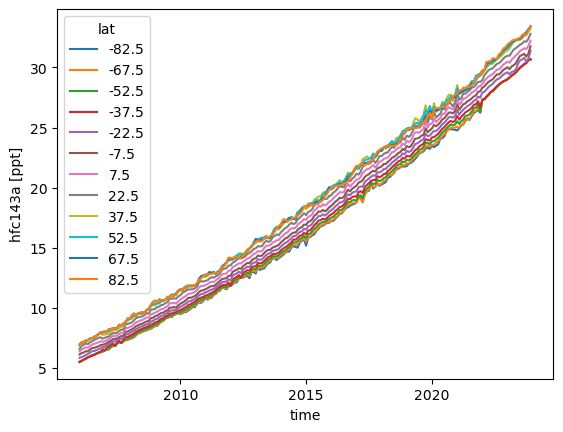

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

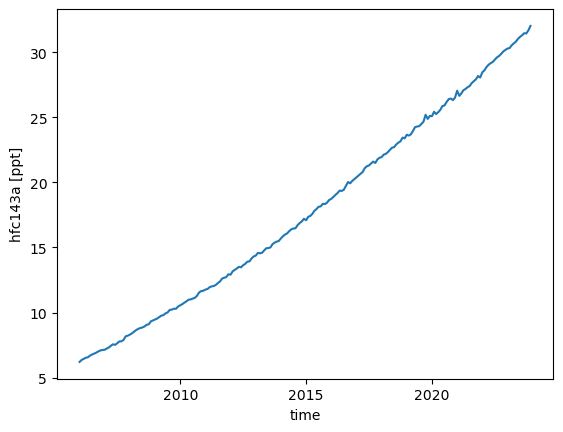

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

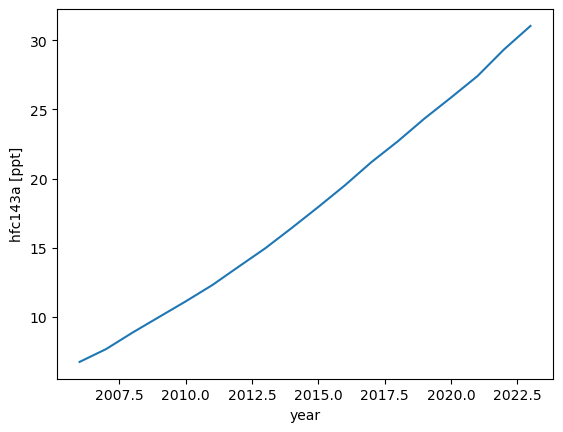

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 18)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 144B 2006 2007 2008 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4108 ... -0.05329
    principal-components  (year, eof) float64 2kB [] -2.182 ... 5.388e-16

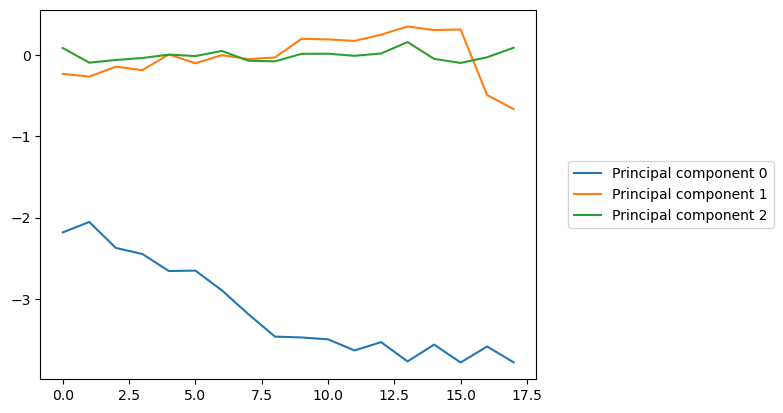

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

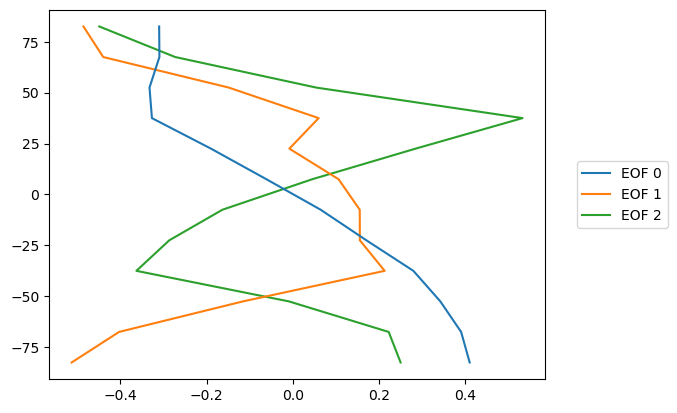

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

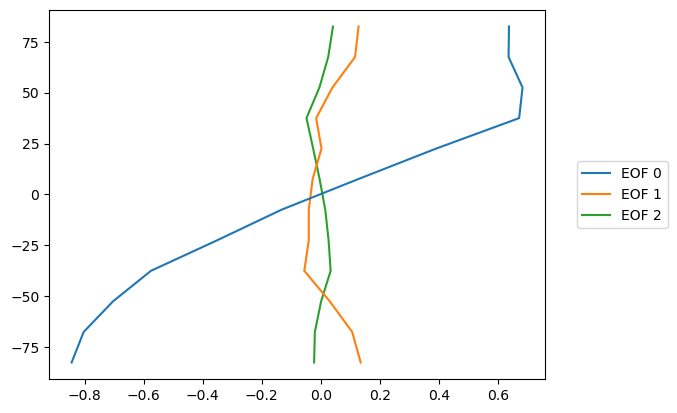

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.4108149469707375] [0.3909795029141613] [0.3426918632565799] [0.28013178234581215] [0.17098648479020123] [0.06498628872097081] [-0.061176884495903] [-0.18970000714817598] [-0.32684301099556373] [-0.33247092954547086] [-0.3094545807051271] [-0.31006591083796636]]
Units,ppt
Magnitude,[[-2.1819891976413306] [-2.0535466888381535] [-2.3729734399678217] [-2.4478618456638808] [-2.6574411914023184] [-2.65250519987433] [-2.896161087353494] [-3.1896544992106723] [-3.465241300167079] [-3.4759640667404352] [-3.4992409608221666] [-3.6359184096671977] [-3.533607948243873] [-3.7714900426816227] [-3.563831869992681] [-3.784116180737389] [-3.5875596565667762] [-3.7828467543255826]]
Units,dimensionless


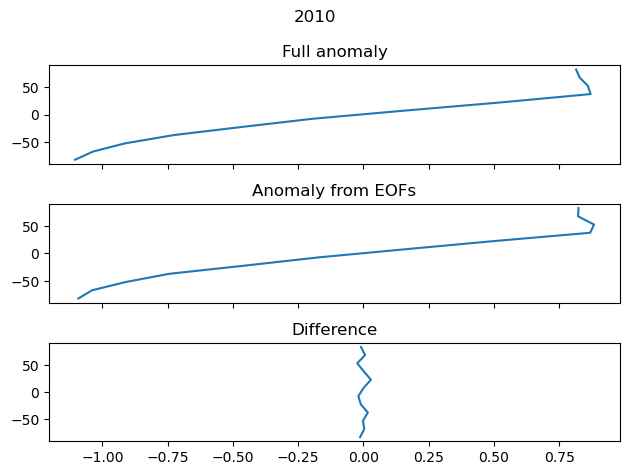

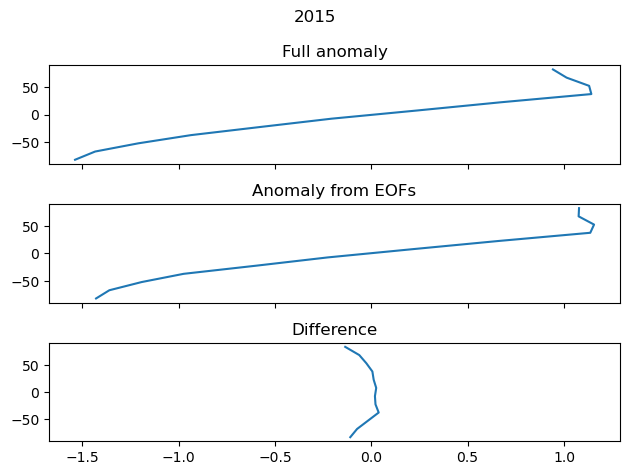

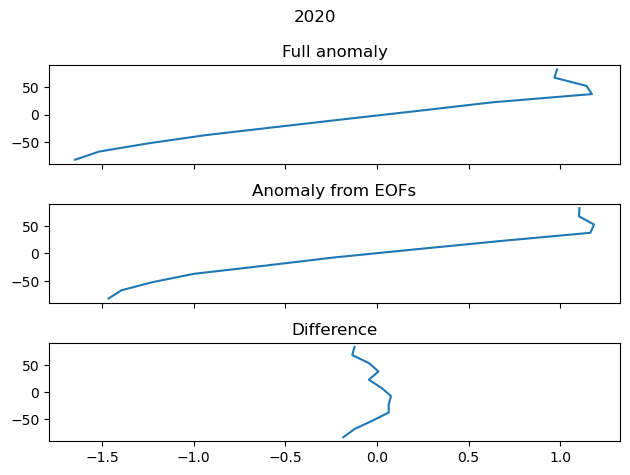

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/216 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 216/216 [00:00<00:00, 17896.76it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/216 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/216 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 216/216 [00:00<00:00, 19025.78it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/216 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 216/216 [00:00<00:00, 19608.04it/s]

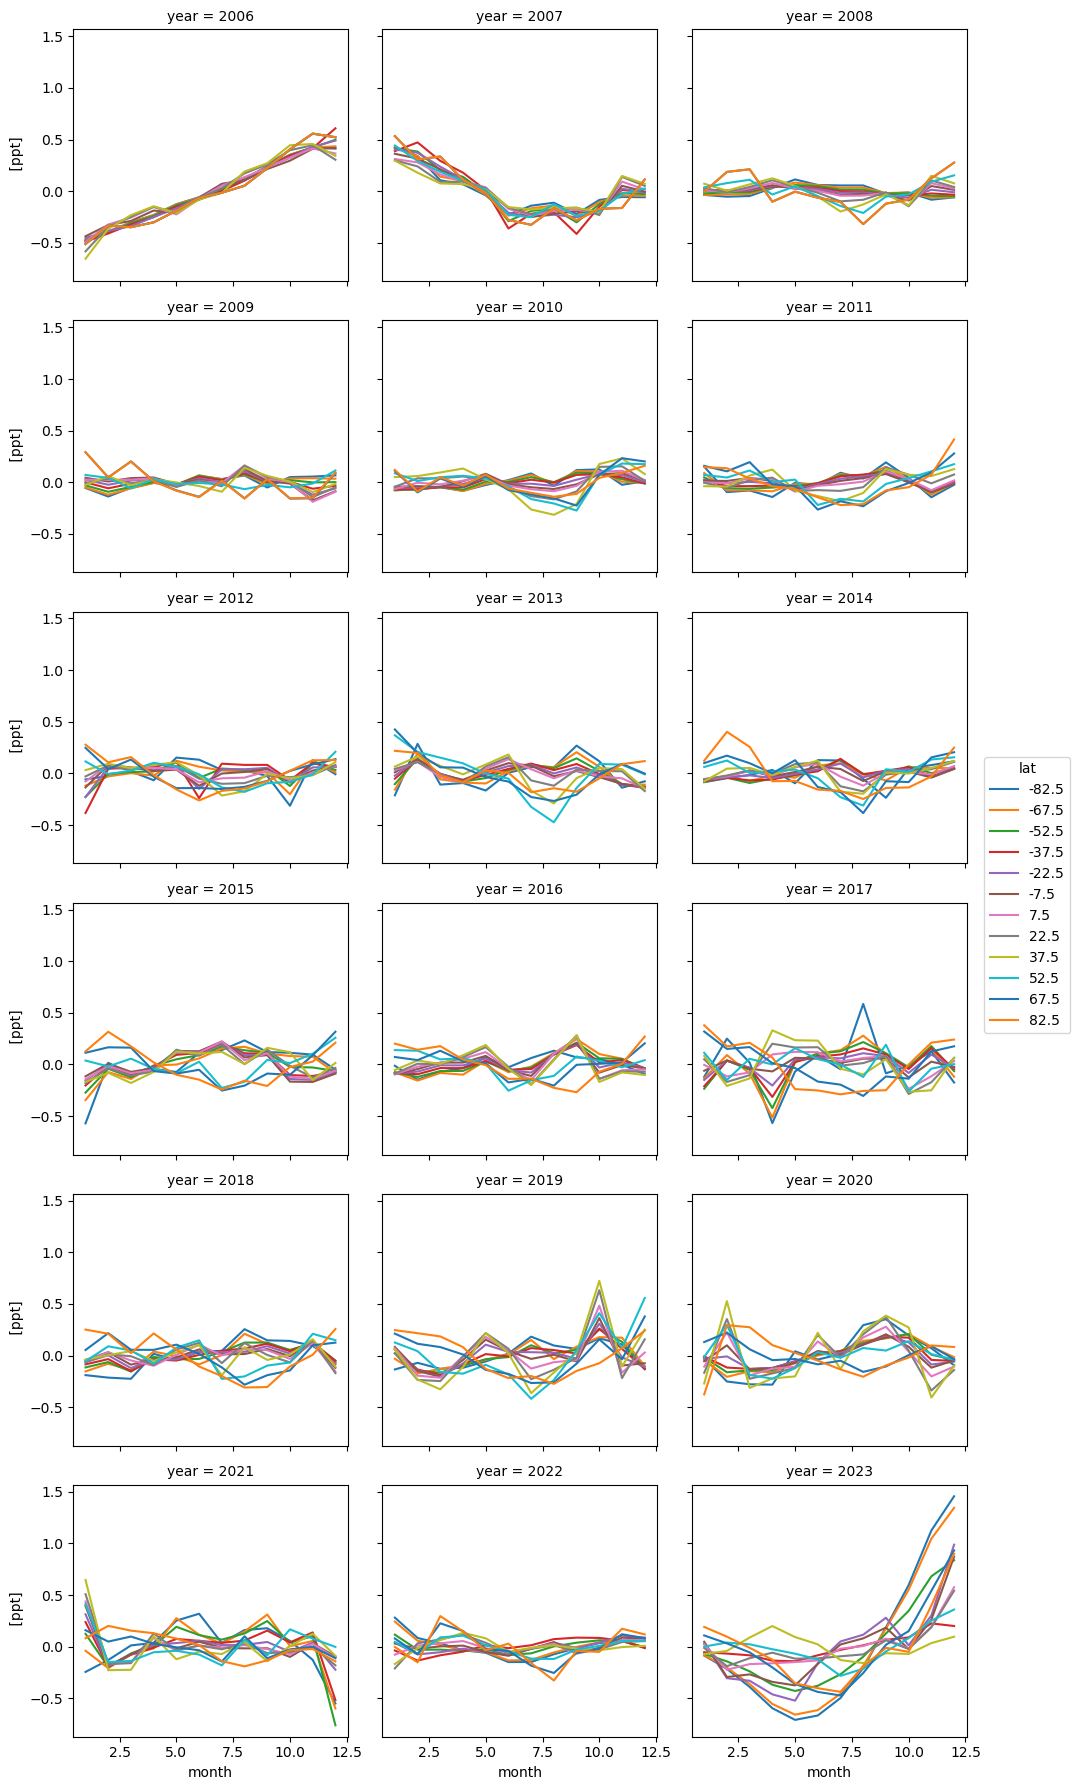

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

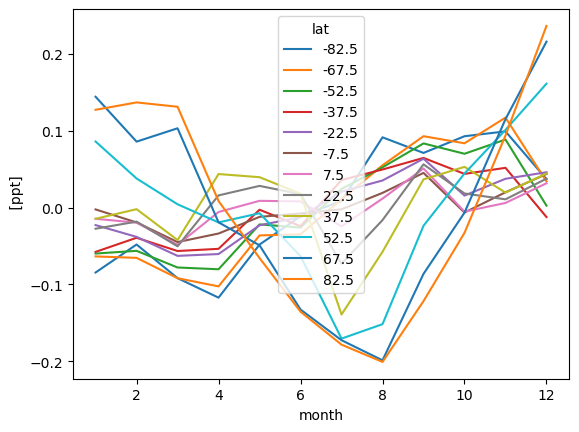

In [22]:
seasonality.plot.line(hue="lat")

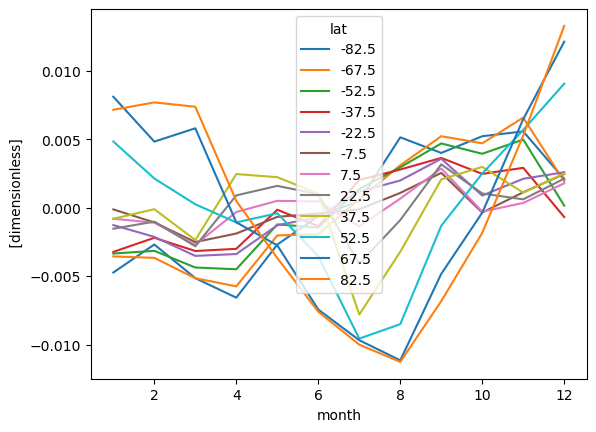

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[6.719233998647465 7.649807166141944 8.847535266978356 9.975544732197669 11.101974423112608 12.27798700714663 13.619708870828681 14.94606212980719 16.421413680521457 17.938606807478003 19.50143901542457 21.182826619748152 22.69639233651522 24.33628326326409 25.85658392854622 27.41460670833106 29.342086335355845 31.04924158994687]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.4108149469707375] [0.3909795029141613] [0.3426918632565799] [0.28013178234581215] [0.17098648479020123] [0.06498628872097081] [-0.061176884495903] [-0.18970000714817598] [-0.32684301099556373] [-0.33247092954547086] [-0.3094545807051271] [-0.31006591083796636]]
Units,ppt
Magnitude,[[-2.1819891976413306] [-2.0535466888381535] [-2.3729734399678217] [-2.4478618456638808] [-2.6574411914023184] [-2.65250519987433] [-2.896161087353494] [-3.1896544992106723] [-3.465241300167079] [-3.4759640667404352] [-3.4992409608221666] [-3.6359184096671977] [-3.533607948243873] [-3.7714900426816227] [-3.563831869992681] [-3.784116180737389] [-3.5875596565667762] [-3.7828467543255826]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.004738044884481484 -0.002692459741620817 -0.005149465358007531 -0.006575478072379783 -0.0026973419119760223 -0.0006314266549109669 0.00048648996156081366 0.005136578423755368 0.003995884450624007 0.005215391684444624 0.0055700488024339094 0.00207989846241692] [-0.0035629470789489454 -0.0036679310935808125 -0.005153743190902023 -0.005750230497912691 -0.0020290646968799775 -0.001946594417580484 0.0006119344405869742 0.00309332183559991 0.005217032268453669 0.004700226488209736 0.006575749721865124 0.0019123109997254775] [-0.0033527352210094173 -0.0031546758435614035 -0.004371336124476871 -0.004500590860661388 -0.001223494167159294 -0.0014558285809345853 0.0013652872104553326 0.0029458097574284387 0.004689432449709812 0.0039354463153699094 0.004975289224671318 0.00014741347291807392] [-0.003232074194948435 -0.002201269869429235 -0.0031681702625275306 -0.0030084557452886977 -0.0001525073726732268 -0.0013591799388095072 0.0020174917464665662 0.0027857358289294183 0.003631782508069903 0.002464633245416719 0.002908088913123395 -0.0006861162667122009] [-0.001272787037314682 -0.00213521496810147 -0.003522838438635861 -0.0033898287132320512 -0.0012895436326889967 -0.0006905741721582218 0.0011694914137806397 0.0019829443742877084 0.0035721605021247138 0.0008824054661401766 0.0021078373041977768 0.0025859487193355245] [-0.00012979519000412093 -0.0010815734000418134 -0.002515101077555643 -0.0018908338791199645 -0.0006735580995969016 -0.0004245076844480968 -0.00012161281103096514 0.001076389287458283 0.0025392304155426055 -0.000357856976207603 0.0011226734813825445 0.0024565401391680583] [-0.000812780402271605 -0.0010961658111211642 -0.002710808829376655 -0.0003190245522676717 0.000498244705748654 0.00045661485574453463 -0.001369241750326101 0.0006591914163736847 0.0028612438964320877 -0.0002902615139128531 0.00034238756951039114 0.0017805732861684487] [-0.001539633690250937 -0.0010216584381219688 -0.002823252490221417 0.0008943586430677497 0.0015886700306437908 0.0009848710724375362 -0.004096791970037989 -0.0009092720777883276 0.003162367996225386 0.0010351952521275229 0.000606716261948035 0.002118400896202803] [-0.0008137850190697155 -0.00011166897483781109 -0.002366525337221172 0.0024535706391144133 0.0022242837909415567 0.0010187492696047862 -0.00780751063977295 -0.0032254730490200697 0.0020627273431546257 0.0029790341943472355 0.0010988183313089847 0.0024877207975364177] [0.004831152555199148 0.0021300926007753293 0.0002457457557962445 -0.0010791057902161914 -0.0004090220542975739 -0.0035420851133850686 -0.009566124533608087 -0.008510873733375182 -0.0013242740599497226 0.0024926166166991917 0.005677184428742683 0.009054657494425102] [0.008099935199307816 0.004822041398345891 0.005795593585020227 -0.0010729531848082357 -0.002752933475968298 -0.007443422539013102 -0.009682767188537082 -0.011152835940289783 -0.0048369520954633614 -0.00036618787219544577 0.006466334444755799 0.01212416323810202] [0.007146828276766905 0.00768537636993141 0.007368717931947698 0.0004832534956979992 -0.0036824268740562067 -0.007599172564772181 -0.01000659755694342 -0.011268775878248562 -0.006828948744156072 -0.0018400960591290084 0.005269060125893915 0.013272793512770612]]
Units,dimensionless
